<a href="https://colab.research.google.com/github/emzu/futureIDF/blob/main/04)_PGH_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization

In [7]:
from google.colab import drive
drive.mount('/content/drive')

try:
    !git clone "https://github.com/emzu/futureIDF"
except:
    print("Already cloned")

%cd /content/futureIDF
!git pull

# Load Packages
!pip install -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'futureIDF'...
remote: Enumerating objects: 2633, done.
remote: Counting objects: 100% (500/500), done.
remote: Compressing objects: 100% (417/417), done.
remote: Total 2633 (delta 117), reused 448 (delta 80), pack-reused 2133 (from 2)
Receiving objects: 100% (2633/2633), 317.64 MiB | 29.42 MiB/s, done.
Resolving deltas: 100% (380/380), done.
Updating files: 100% (2560/2560), done.
/content/futureIDF
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 740 bytes | 148.00 KiB/s, done.
From https://github.com/emzu/futureIDF
   b9cf265..4e34aee  main       -> origin/main
Updating b9cf265..4e34aee
Fast-forward
 modules/data_io.py | 10 +++++++++-
 1 file changed, 9 insertion

In [2]:
!pip install -r requirements.txt
!pip install zarr
!pip install rasterio
!pip install rioxarray
!pip install regionmask

In [11]:
!git pull

# Import modules
import sys
import importlib
# Ensure workspace root is on sys.path so the local `modules` package can be imported
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os

from modules import config, data_io, timeseries, plotting, process_rp, geospatial
importlib.reload(timeseries)
importlib.reload(data_io)
importlib.reload(process_rp)
importlib.reload(geospatial)

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 326 bytes | 163.00 KiB/s, done.
From https://github.com/emzu/futureIDF
   4e34aee..0e7bf2f  main       -> origin/main
Updating 4e34aee..0e7bf2f
Fast-forward
 modules/data_io.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


<module 'modules.geospatial' from '/content/futureIDF/modules/geospatial.py'>

In [3]:
import numpy as np
import xarray as xr
import zarr
import rasterio
import rioxarray
from scipy.stats import bernoulli, gamma
from rasterio import features
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

import xarray as xr
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator

In [4]:
from dask.diagnostics import ProgressBar

pbar = ProgressBar()
pbar.register()

In [5]:
plt.rcParams.update({
    # Font sizes
    'font.size': 16,           # Base font size
    'axes.labelsize': 20,      # x and y labels
    'axes.titlesize': 22,      # Subplot titles
    'xtick.labelsize': 16,     # x tick labels
    'ytick.labelsize': 16,     # y tick labels
    'legend.fontsize': 16,     # Legend
    'figure.titlesize': 24,    # Figure title

    # Line widths
    'axes.linewidth': 2,       # Axes border
    'lines.linewidth': 2.5,    # Plot lines
    'patch.linewidth': 2,      # Bar edges, etc.
    'grid.linewidth': 1.5,     # Grid lines

    # Tick parameters
    'xtick.major.size': 8,     # x tick length
    'ytick.major.size': 8,     # y tick length
    'xtick.major.width': 2,    # x tick width
    'ytick.major.width': 2,    # y tick width

    # Other
    'figure.dpi': 150,         # Higher resolution
    'savefig.dpi': 300,        # High res when saving
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
})

# Compute Effective Return Periods


In [12]:
atlas14_counties = data_io.a14_county_gdf(a14_PATH="/content/futureIDF/data/Atlas14/atlas14_24hr_data.parquet")

In [14]:
adjFactors_LOCA = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/FINAL_COMBINED/adj_factors_combined_LOCA_lmom_smoothedcentroid_nb100_1950_2000.zarr", consolidated = False)
adjFactors_LOCA2 = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/FINAL_COMBINED/adj_factors_combined_LOCA2_lmom_smoothedcentroid_nb100_1950_2000.zarr", consolidated = False)

In [16]:
county = "Allegheny"
time_period = '2050-2100'

##### Compute Effective Return Periods #####
atlas14_pgh = atlas14_counties[atlas14_counties['county_name']== county][['2', '5', '10', '25', '50', '100', '200', '500']].astype(float).values[0]

ds_zarr_LOCA2 = adjFactors_LOCA2.sel(county = str(atlas14_counties[atlas14_counties['county_name']== county].index.values[0]))['adj_factor'].mean(dim = 'centroid_cell').sel(time_period = time_period)
ds_zarr_LOCA2_45 = ds_zarr_LOCA2.sel(scenario = 'ssp245')
ds_zarr_LOCA2_85 = ds_zarr_LOCA2.sel(scenario = 'ssp585')

ds_zarr_LOCA = adjFactors_LOCA.sel(county = str(atlas14_counties[atlas14_counties['county_name']== county].index.values[0]))['adj_factor'].mean(dim = 'centroid_cell').sel(time_period = time_period)
ds_zarr_LOCA_45 = ds_zarr_LOCA.sel(scenario = 'rcp45')
ds_zarr_LOCA_85 = ds_zarr_LOCA.sel(scenario = 'rcp85')

#Reference Change Factors
change_factors_ssp245 = ds_zarr_LOCA2_45.median(dim = ['model', 'n_b']).values
change_factors_ssp585 = ds_zarr_LOCA2_85.median(dim = ['model', 'n_b']).values

change_factors_rcp45 = ds_zarr_LOCA_45.median(dim = ['model', 'n_b']).values
change_factors_rcp85 = ds_zarr_LOCA_85.median(dim = ['model', 'n_b']).values

##### DESIGN FACTORS #####

DESIGN_FACTOR_BASE = 1
design_factors_a14 = ds_zarr_LOCA2_45.median(dim = ['model', 'n_b']).values*0+DESIGN_FACTOR_BASE

DESIGN_FACTOR_10RP = 1.15
design_factors_pgh_10 = ds_zarr_LOCA2_45.median(dim = ['model', 'n_b']).values*0+DESIGN_FACTOR_10RP

DESIGN_FACTOR_100RP = 1.23
design_factors_pgh_100 = ds_zarr_LOCA2_45.median(dim = ['model', 'n_b']).values*0+DESIGN_FACTOR_100RP

[########################################] | 100% Completed | 1.13 s
[########################################] | 100% Completed | 6.17 s
[########################################] | 100% Completed | 51.36 s
[########################################] | 100% Completed | 45.77 s
[########################################] | 100% Completed | 1.12 s
[########################################] | 100% Completed | 1.13 s
[########################################] | 100% Completed | 1.22 s


In [ ]:
#Basline
LOCA_values_45 = timeseries.process_inversion(ds_zarr_LOCA_45, atlas14_pgh, design_factors_a14)
LOCA_values_85 = timeseries.process_inversion(ds_zarr_LOCA_85, atlas14_pgh, design_factors_a14)

LOCA2_values_45 = timeseries.process_inversion(ds_zarr_LOCA2_45, atlas14_pgh, design_factors_a14)
LOCA2_values_85 = timeseries.process_inversion(ds_zarr_LOCA2_85, atlas14_pgh, design_factors_a14)

#PGH 10-yr
LOCA_values_45_pgh_10 = timeseries.process_inversion(ds_zarr_LOCA_45, atlas14_pgh, design_factors_pgh_10)
LOCA_values_85_pgh_10 = timeseries.process_inversion(ds_zarr_LOCA_85, atlas14_pgh, design_factors_pgh_10)

LOCA2_values_45_pgh_10 = timeseries.process_inversion(ds_zarr_LOCA2_45, atlas14_pgh, design_factors_pgh_10)
LOCA2_values_85_pgh_10 = timeseries.process_inversion(ds_zarr_LOCA2_85, atlas14_pgh, design_factors_pgh_10)

#PGH 100-yr
LOCA_values_45_pgh_100 = timeseries.process_inversion(ds_zarr_LOCA_45, atlas14_pgh, design_factors_pgh_100)
LOCA_values_85_pgh_100 = timeseries.process_inversion(ds_zarr_LOCA_85, atlas14_pgh, design_factors_pgh_100)

LOCA2_values_45_pgh_100 = timeseries.process_inversion(ds_zarr_LOCA2_45, atlas14_pgh, design_factors_pgh_100)
LOCA2_values_85_pgh_100 = timeseries.process_inversion(ds_zarr_LOCA2_85, atlas14_pgh, design_factors_pgh_100)

[########################################] | 100% Completed | 1.74 s
[########################################] | 100% Completed | 1.74 s
[########################################] | 100% Completed | 2.10 s
[########################################] | 100% Completed | 2.04 s
[########################################] | 100% Completed | 1.75 s
[########################################] | 100% Completed | 1.74 s
[########################################] | 100% Completed | 1.88 s
[########################################] | 100% Completed | 1.85 s
[########################################] | 100% Completed | 1.75 s
[########################################] | 100% Completed | 2.25 s
[########################################] | 100% Completed | 1.91 s
[########################################] | 100% Completed | 1.75 s
[########################################] | 100% Completed | 1.13 s
[########################################] | 100% Completed | 1.12 s
[#################################

# Pittsburgh Adjustment Factor

In [ ]:
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         8,
    "axes.labelsize":    8,
    "axes.titlesize":    9,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})


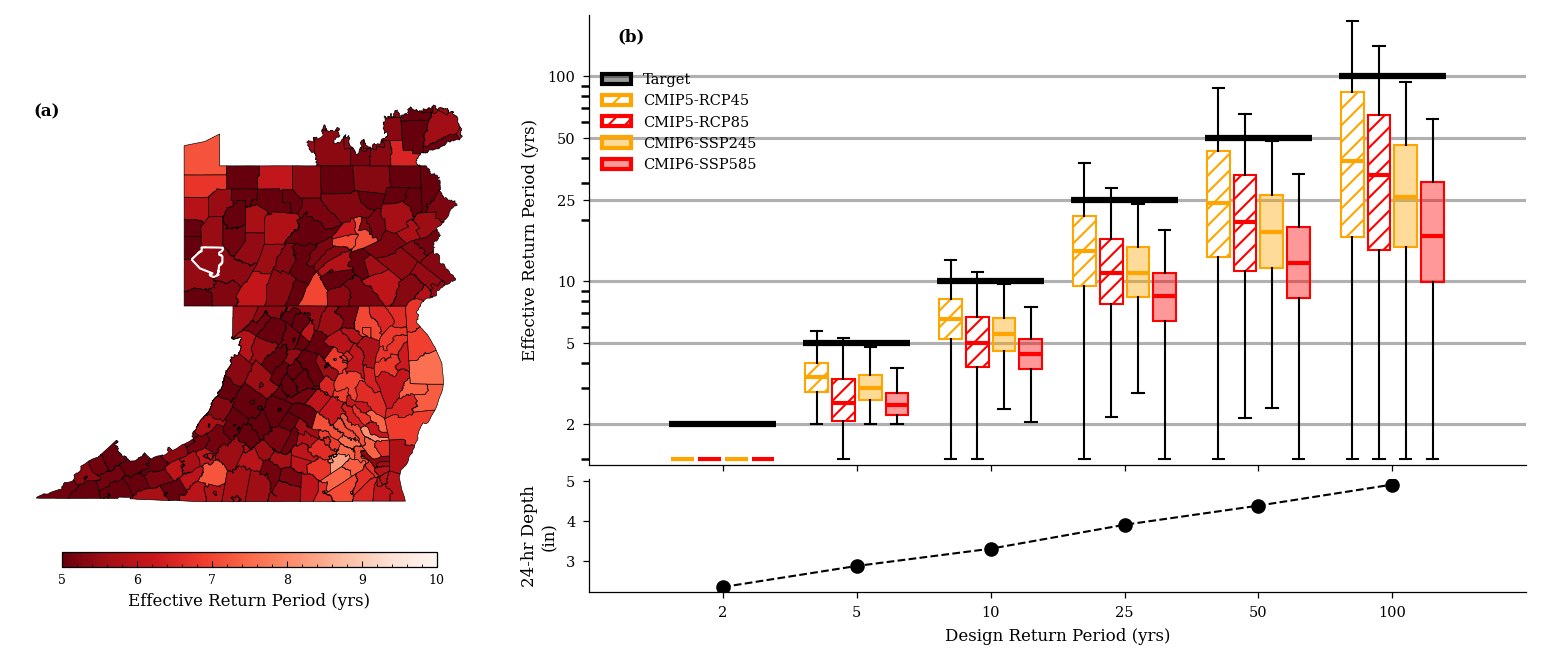

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec



fig, axs = plt.subplots(2, 1, sharex=True, figsize=(5, 3),
    gridspec_kw={'height_ratios': [4, 1]})

ax_box = axs[0]
ax_idf = axs[1]

x_vals    = np.array([2, 5, 10, 25, 50, 100])
positions = np.arange(len(x_vals))
offsets   = [-0.3, -0.1, 0.1, 0.3]
box_width = 0.17

def to_rgba(color, alpha):
    r, g, b, _ = mcolors.to_rgba(color)
    return (r, g, b, alpha)

datasets = [
    (LOCA_values_45,  'orange', '///', 'CMIP5-RCP45'),
    (LOCA_values_85,  'red',    '///', 'CMIP5-RCP85'),
    (LOCA2_values_45, 'orange', '',    'CMIP6-SSP245'),
    (LOCA2_values_85, 'red',    '',    'CMIP6-SSP585'),
]

for (raw_data, color, hatch, label), offset in zip(datasets, offsets):
    data = data_io.clean_values(raw_data[:6])
    color_dict = {
        'boxes':    color,
        'whiskers': 'black',
        'medians':  color,
        'caps':     'black',
    }
    facecolor = 'white' if hatch else to_rgba(color, 0.4)
    data.boxplot(
        positions=positions + offset,
        widths=box_width,
        patch_artist=True,
        color=color_dict,
        boxprops=dict(facecolor=facecolor, hatch=hatch, edgecolor=color),
        flierprops=dict(marker=''),
        medianprops=dict(color=color, linewidth=2),
        ax=ax_box,
    )

for i, ref_val in enumerate(x_vals):
    ax_box.hlines(y=ref_val, xmin=i-0.4, xmax=i+0.4, colors='black', linewidth=3)

ax_box.set_yscale('symlog', linthresh=2, linscale=0.3)
ax_box.set_yticks([2, 5, 10, 25, 50, 100])
ax_box.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}' if x > 0 else ''))
ax_box.set_ylim([0.8, 200])

minor_ticks = [1, 3, 4, 6, 7, 8, 9, 10, 20, 30, 40, 60, 70, 80, 90]
ax_box.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks))
ax_box.tick_params(which='minor', length=4, width=1.2, color='black')
ax_box.set_ylabel("Effective Return Period (yrs)")
ax_box.tick_params(labelbottom=False)
ax_box.text(0.03, 0.97, "(b)", transform=ax_box.transAxes,
            fontsize=8, fontweight="bold", va="top", ha="left")

# legend
colors  = ['black', 'orange', 'red',   'orange',      'red']
hatches = ['',      '///',    '///',   '',             '']
labels  = ['Target', 'CMIP5-RCP45', 'CMIP5-RCP85', 'CMIP6-SSP245', 'CMIP6-SSP585']
patches = [mpatches.Patch(facecolor='white' if h else to_rgba(c, 0.4),
                          edgecolor=c, hatch=h, label=l)
           for c, h, l in zip(colors, hatches, labels)]
ax_box.legend(handles=patches, loc='upper left', frameon=False,
              bbox_to_anchor=(0.0, 0.90))
ax_box.xaxis.grid(False)

# ── IDF strip ─────────────────────────────────────────────────────────────────
a14 = atlas14_pgh[:6]
ax_idf.plot(positions, a14, 'o--', color='black', label='Atlas 14', linewidth=1)

idf_datasets = [
    (change_factors_rcp45,  'orange', '--', 'CMIP5-RCP45'),
    (change_factors_rcp85,  'red',    '--', 'CMIP5-RCP85'),
    (change_factors_ssp245, 'orange', '-',  'CMIP6-SSP245'),
    (change_factors_ssp585, 'red',    '-',  'CMIP6-SSP585'),
]

ax_idf.set_xlabel("Design Return Period (yrs)")
ax_idf.set_ylabel("24-hr Depth\n(in)")
ax_idf.set_xlim([-1, 6])
ax_idf.set_xticks(positions)
ax_idf.set_xticklabels(x_vals)

fig.savefig("combined_map_boxplot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("combined_map_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

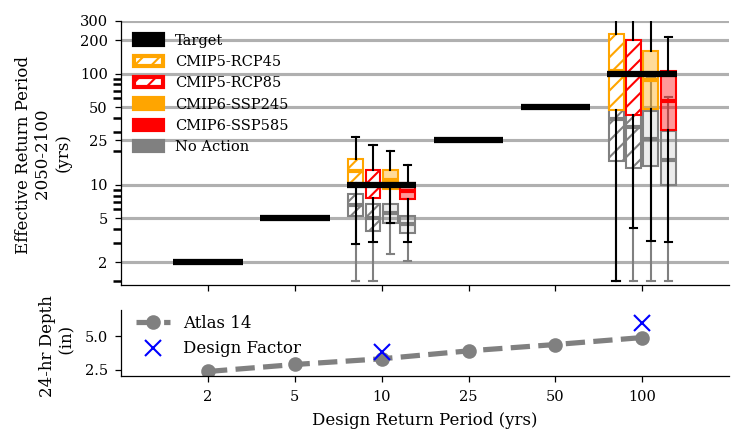

In [ ]:
# @title
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import pandas as pd

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(5, 3),
    gridspec_kw={'height_ratios': [4, 1]})

###### Boxplot ######
ax = axs[0]
x_vals = np.array([2, 5, 10, 25, 50, 100])
positions = np.arange(len(x_vals))
highlight_positions = [2, 5]  # indices of 10yr and 100yr in x_vals

offsets = [-0.3, -0.1, 0.1, 0.3]
box_width = 0.17

def to_rgba(color, alpha):
    r, g, b, _ = mcolors.to_rgba(color)
    return (r, g, b, alpha)

datasets = [
    (LOCA_values_45,  'orange', '///', 'CMIP5-RCP45'),
    (LOCA_values_85,  'red',    '///', 'CMIP5-RCP85'),
    (LOCA2_values_45, 'orange', '',    'CMIP6-SSP245'),
    (LOCA2_values_85, 'red',    '',    'CMIP6-SSP585'),
]

# --- Gray background boxes (all positions) ---
for (raw_data, color, hatch, label), offset in zip(datasets, offsets):
    data = data_io.clean_values(raw_data)
    data = data [[10, 100]]
    color_dict = {
        'boxes': 'gray',
        'whiskers': 'gray',
        'medians': 'gray',
        'caps': 'gray'
    }
    facecolor = to_rgba('gray', 0.15) if not hatch else 'white'
    data.boxplot(
        positions=np.array(highlight_positions) + offset,
        widths=box_width,
        patch_artist=True,
        color=color_dict,
        boxprops=dict(facecolor=facecolor, hatch=hatch if hatch else '', edgecolor='gray'),
        flierprops=dict(marker=''),
        medianprops=dict(color='gray', linewidth=2),
        ax=ax,
        zorder=2
    )

# --- Highlighted boxes for 10yr (index 2) and 100yr (index 5) ---
highlight_datasets = [
    (LOCA_values_45_pgh_10,  LOCA_values_45_pgh_100,  'orange', '///', 'CMIP5-RCP45'),
    (LOCA_values_85_pgh_10,  LOCA_values_85_pgh_100,  'red',    '///', 'CMIP5-RCP85'),
    (LOCA2_values_45_pgh_10, LOCA2_values_45_pgh_100, 'orange', '',    'CMIP6-SSP245'),
    (LOCA2_values_85_pgh_10, LOCA2_values_85_pgh_100, 'red',    '',    'CMIP6-SSP585'),
]

for (data_10, data_100, color, hatch, label), offset in zip(highlight_datasets, offsets):
    facecolor = 'white' if hatch else to_rgba(color, 0.4)
    color_dict = {
        'boxes': color,
        'whiskers': 'black',
        'medians': color,
        'caps': 'black'
    }
    for pos_idx, data in zip(highlight_positions, [data_10, data_100]):
        rp_data = data_io.clean_values(data[:6])
        rp_data = rp_data[[x_vals[pos_idx]]]
        rp_data.boxplot(
            positions=[pos_idx + offset],
            widths=box_width,
            patch_artist=True,
            color=color_dict,
            boxprops=dict(facecolor=facecolor, hatch=hatch, edgecolor=color),
            flierprops=dict(marker=''),
            medianprops=dict(color=color, linewidth=2),
            ax=ax,
            zorder=3
        )

# Reference lines (target return periods)
for i, ref_val in enumerate(x_vals):
    ax.hlines(y=ref_val, xmin=i-0.4, xmax=i+0.4, colors='black', linewidth=3, zorder=4)

ax.set_yscale('symlog', linthresh=2, linscale=0.3)
ax.set_yticks([2, 5, 10, 25, 50, 100, 200, 300])
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}' if x > 0 else ''))
ax.set_ylim([0.8, 300])

minor_ticks = [1, 3, 4, 6, 7, 8, 9, 10, 20, 30, 40, 60, 70, 80, 90]
ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks))
ax.tick_params(which='minor', length=4, width=1.2, color='black')
ax.xaxis.grid(False)
ax.yaxis.grid(True)
ax.set_ylabel("Effective Return Period \n2050-2100 \n(yrs)")

###### Plot Baseline IDF Curve ######
ax = axs[1]
a14 = atlas14_pgh[:6]

ax.plot(positions, a14, 'o--', color='gray', label='Atlas 14')
ax.plot([2], np.round(1.15 * a14[2], 2), 'x', markersize=8, color='blue', label='Design Factor')
ax.plot([5], np.round(1.23 * a14[5], 2), 'x', markersize=8, color='blue', label='_nolabel')


ax.set_xlabel("Design Return Period (yrs)")
ax.set_ylabel("24-hr Depth \n (in)")
ax.xaxis.grid(False)
ax.set_ylim(2, 7)
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(0.0, 1.15), frameon=False)
# Legend for top panel
colors  = ['black', 'orange', 'red',        'orange',      'red',         'gray']
hatches = ['',      '///',    '///',         '',            '',            '']
labels  = ['Target','CMIP5-RCP45', 'CMIP5-RCP85', 'CMIP6-SSP245', 'CMIP6-SSP585', 'No Action']
patches = [mpatches.Patch(facecolor='white' if h else to_rgba(c, 1),
                          edgecolor=c, hatch=h, label=l)
           for c, h, l in zip(colors, hatches, labels)]
axs[0].legend(handles=patches, loc='upper left', frameon=False)

plt.xlim([-1, 6])
plt.xticks(positions, x_vals)
plt.tight_layout()
plt.show()

fig.savefig("risk_AC_boxplot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("risk_AC_boxplot.png", dpi=300, bbox_inches="tight")